# Solutions to L12

```{solution} l12-1
:class: dropdown
:label: sol-l12-1
The weak form is $\int u_x v_x + u v dx$.
Letting the matrix of the system be $(a_{ij})_{ij}$, we again see that when $|i - j | > 1$, $a_{ij} = 0$, so our matrix is (again) tridiagonal.
```


```{solution-start} l12-2
:class: dropdown
:label: sol-l12-2
This corresponds to coating an end of the rod in isolating material, meaning that no heat is allowed to flow out of the rod. It can be incorporated into the system of equations by modifying the boundary terms $-u_x(0) v(0) + u_x(1)v(0)$. So if you for example want to enforce $u_x(0) = 0$, just set the term $u_x(0)$ to 0.
```


In [1]:
print("Hello")

Hello


We did this because $a=b$

```{solution-end}
```

```{solution-start} l12-mapping-F
:class: dropdown
:label: sol-l12-mapping-F
We create a convenience function that takes in the coordinates of the vertices of the current cell and the point in the reference element.
```

In [2]:
import basix.ufl
import numpy as np
import matplotlib.pyplot as plt

def compute_physical_point(p0, p1, X):
    """
    Map coordinates `X` in reference element to a line defined by `p0`, `p1`
    """
    el = basix.ufl.element("Lagrange", "interval", 1)
    basis_values = el.tabulate(0, X)
    x = basis_values[0] @ np.vstack([p0, p1])
    return x

cells = np.array([[0,1], [1,2], [2, 3], [3, 4], [4, 6], [6,5]], dtype=np.int64)
nodes = np.array([[0.1], [0.2], [0.4], [0.5],[0.6], [1.], [0.8]], dtype=np.float64)
for cell in cells:
    p0, p1 = nodes[cell]
    X = np.array([[0.5]])
    x = compute_physical_point(p0, p1, X)
    print(f"Cell with vertices {p0}, {p1} has midpoint {x}")

Cell with vertices [0.1], [0.2] has midpoint [[0.15]]
Cell with vertices [0.2], [0.4] has midpoint [[0.3]]
Cell with vertices [0.4], [0.5] has midpoint [[0.45]]
Cell with vertices [0.5], [0.6] has midpoint [[0.55]]
Cell with vertices [0.6], [0.8] has midpoint [[0.7]]
Cell with vertices [0.8], [1.] has midpoint [[0.9]]


```{solution-end}
```
```{solution-start} l12-mapping-tetra-F
:class: dropdown
:label: sol-l12-mapping-tetra-F
We repeat the procedure from earlier and visualize with matplotlib
```

TypeError: 'Text' object is not callable

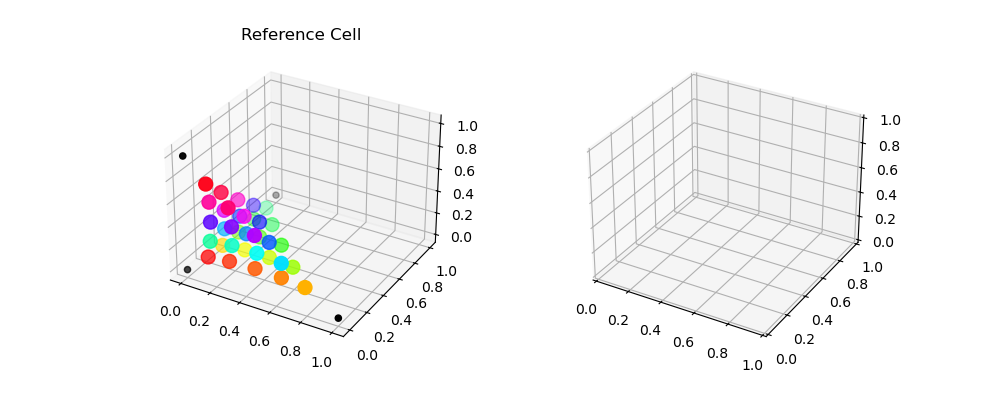

In [ ]:
%matplotlib widget
def compute_physical_point(points,cell_type, X):
    """
    Map coordinates `X` in reference element to a cell defined by `points` and `cell_type`
     
    Args:
        points: an array of shape (num_vertices, geometric_dimension)
        cell_type: a string, e.g. "interval", "triangle", "quadrilateral"
        X:is an array of shape (num_points, topological_dimension)
     
    Returns:
        An array of shape (num_points, geometric_dimension)
    """
    el = basix.ufl.element("Lagrange", cell_type, 1)
    basis_values = el.tabulate(0, X)
    return basis_values[0] @ points

points = np.array([[0.1, 0, 0], [0.4, 0.6, 0], [0.8, 0.7, 0.2], [0, 0, 1]], dtype=np.float64)
reference_points = basix.create_lattice(
    basix.CellType.tetrahedron, 8, basix.LatticeType.gll, exterior=False, method=basix.LatticeSimplexMethod.warp
)
node_colors = np.arange(reference_points.shape[0])
X_p = compute_physical_point(points, "tetrahedron", reference_points)
fig,(ax_ref, ax) = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': '3d'})
ref_vertices = basix.geometry(basix.CellType.tetrahedron)
ax_ref.set_title("Reference Cell")
ax_ref.scatter(ref_vertices[:, 0], ref_vertices[:, 1], ref_vertices[:, 2], color='black', label='Vertices')
ax_ref.scatter(reference_points[:, 0], reference_points[:, 1], reference_points[:, 2], c=node_colors, cmap='hsv', s=100)

ax.set_title("Physical Cell")
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='black', label='Vertices')
ax.scatter(X_p[:, 0], X_p[:, 1], X_p[:, 2], label='Mapped Points', cmap='hsv', s=100, c=node_colors)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

```{solution-end}
```